# Linear Regression Model — Airbnb Rome Price Prediction (v3)

Rebuilt to use `final_dataset.csv` (now produced by `05_final_dataset.ipynb`) and to apply
**the exact same preprocessing pipeline as `06_random_forest.ipynb`**, so that Linear Regression
and Random Forest are trained and evaluated on the same rows, the same features, and the same
train/test split. That's what makes comparing their MAE/RMSE/R² meaningful.

The only intentional difference from the Random Forest notebook: numeric features are
**standardized** before fitting (`StandardScaler`), since Linear Regression coefficients are
scale-sensitive and comparable coefficient magnitudes are useful for the Feature Selection
part of the presentation. Random Forest doesn't need scaling, so its notebook skips it.


## Status check (05/06/07 alignment)

- `05_final_dataset.ipynb` merges `listings_features.csv` (key: `id`) with
  `review_features.csv` (key: `listing_id`) via a left join, fills missing review features with
  0, and adds `days_since_latest_review`. It exports `data/final_dataset.csv`. This now runs
  end-to-end — the earlier "0 bytes" blocker is resolved.
- `id` is present in `candidate_features` in `02_listings_cleaning.ipynb`, so the merge key
  issue is resolved.
- `final_dataset.csv` contains **both** `last_review` (raw datetime, carried over from
  `listings.csv` via `listings_features.csv`) **and** `latest_review_date` (computed in
  `03_reviews_analysis.ipynb`, merged in step 05). `06_random_forest.ipynb` uses both: it
  decomposes `latest_review_date` into year/month/day and computes `days_since_last_review`
  from `last_review`. This notebook mirrors that exactly, so the resulting feature sets match.
- `property_type`, `room_type`, `instant_bookable` remain raw text columns in
  `final_dataset.csv` (only `neighbourhood_cleansed` is one-hot encoded upstream, in step 02),
  matching what both model notebooks expect.

**Remaining thing worth a quick sync with the group:** `neighbourhood_cleansed` is one-hot
encoded in `02_listings_cleaning.ipynb` *without* `drop_first`, so those dummy columns are
collinear (they always sum to 1 across each row). This doesn't break either model, but it means
individual `neighbourhood_cleansed_*` coefficients in the Linear Regression output below aren't
individually interpretable in isolation — worth a footnote in the presentation if you show them.


## 1. Setup

In [19]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
RANDOM_STATE = 42

print("Project root:", PROJECT_ROOT)


Project root: /Users/juandavid/Desktop/data/airbnb-rome-analysis


## 2. Load the final dataset

Same source file as `06_random_forest.ipynb`: `data/final_dataset.csv`, produced by
`05_final_dataset.ipynb`. No fallback to `listings_features.csv` alone anymore — the merge
notebook runs cleanly now, so both models should be trained on the merged dataset.


In [20]:
final_path = PROJECT_ROOT / "data" / "final_dataset.csv"

if not final_path.exists():
    raise FileNotFoundError(
        f"Could not find {final_path}.\n"
        "Run 05_final_dataset.ipynb first (it merges listings_features.csv and "
        "review_features.csv and exports final_dataset.csv)."
    )

df = pd.read_csv(final_path)

print("Loaded final_dataset.csv -- shape:", df.shape)
df.head()


Loaded final_dataset.csv -- shape: (34324, 64)


,id,price,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,bathrooms,...,neighbourhood_cleansed_XII Monte Verde,neighbourhood_cleansed_XIII Aurelia,neighbourhood_cleansed_XIV Monte Mario,neighbourhood_cleansed_XV Cassia/Flaminia,distance_to_colosseum,location_cluster,review_count,avg_review_length,latest_review_date,days_since_latest_review
0,2737,59.52,41.87136,12.48215,Private Room,Private room,1,1.0,1.0,1.5,...,False,False,False,False,2.252726,2.0,5.0,51.800000,2015-05-08,4077.0
1,12398,117.13,41.92582,12.46928,Apartment,Entire home/apt,3,2.0,3.0,1.0,...,False,False,False,False,4.389669,0.0,85.0,84.658824,2025-08-01,339.0
2,19965,160.60,41.90823,12.45293,Apartment,Entire home/apt,5,2.0,3.0,1.0,...,False,False,False,False,3.824847,0.0,195.0,44.953846,2026-06-13,23.0
3,20534,243.67,41.88992,12.46823,Entire Home,Entire home/apt,4,1.0,3.0,1.0,...,False,False,False,False,1.989591,2.0,50.0,60.200000,2022-11-22,1322.0
4,20587,302.50,41.88992,12.46823,Entire Home,Entire home/apt,4,2.0,4.0,1.0,...,False,False,False,False,1.989591,2.0,90.0,60.622222,2026-04-01,96.0


In [21]:
print(df.shape)

df.info()


(34324, 64)
<class 'pandas.DataFrame'>
RangeIndex: 34324 entries, 0 to 34323
Data columns (total 64 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   id                                                 34324 non-null  int64  
 1   price                                              34324 non-null  float64
 2   latitude                                           34324 non-null  float64
 3   longitude                                          34324 non-null  float64
 4   property_type                                      34324 non-null  str    
 5   room_type                                          34324 non-null  str    
 6   accommodates                                       34324 non-null  int64  
 7   bedrooms                                           34324 non-null  float64
 8   beds                                               34324 non-null  float64
 9   bathr

## 3. Preprocessing — identical to `06_random_forest.ipynb`

The steps below (missing value treatment, date feature engineering, identifier removal,
categorical encoding, outlier treatment) are copied over from the Random Forest notebook
step-for-step. Keeping them identical is what makes the two models' metrics comparable.


### 3.1 Missing Value Treatment

Remaining missing numerical values are replaced using median imputation.

In [22]:
df.isnull().sum().sort_values(
    ascending=False
).head(20)


host_acceptance_rate                           34324
host_experience_days                           34324
host_response_rate                             34324
latest_review_date                              3753
last_review                                     3750
location_cluster                                3337
minimum_nights                                    13
maximum_nights                                    13
neighbourhood_cleansed_IX Eur                      0
neighbourhood_cleansed_IV Tiburtina                0
neighbourhood_cleansed_III Monte Sacro             0
neighbourhood_cleansed_II Parioli/Nomentano        0
id                                                 0
demand_proxy                                       0
occupancy_rate                                     0
review_intensity                                   0
review_recency_days                                0
listing_age_days                                   0
review_quality_index                          

In [ ]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

# Columnas totalmente vacías: la mediana también sería NaN, así que
# fillna(median) no las arregla. Se eliminan en vez de imputarlas.
all_nan_cols = [col for col in numeric_cols if df[col].isnull().all()]
if all_nan_cols:
    print("Dropping fully-empty columns:", all_nan_cols)
    df = df.drop(columns=all_nan_cols)
    numeric_cols = [c for c in numeric_cols if c not in all_nan_cols]

for col in numeric_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

### 3.2 Date Feature Engineering

Review dates are transformed into numerical variables that capture review recency and temporal patterns.

#### Latest Review Date Components

In [24]:
df["latest_review_date"] = pd.to_datetime(
    df["latest_review_date"],
    errors="coerce"
)

df["latest_review_year"] = (
    df["latest_review_date"].dt.year
)

df["latest_review_month"] = (
    df["latest_review_date"].dt.month
)

df["latest_review_day"] = (
    df["latest_review_date"].dt.day
)

df.drop(
    columns=["latest_review_date"],
    inplace=True
)


#### Review Recency

In [25]:
df["days_since_last_review"] = (
    pd.Timestamp.today() - pd.to_datetime(df["last_review"])
).dt.days

In [26]:
df.drop(
    columns=["last_review"],
    inplace=True
)

In [27]:
# Segunda pasada de imputación: cubre las columnas de fecha creadas en 3.2,
# que no existían cuando corrió la imputación de 3.1
date_feature_cols = [
    "latest_review_year",
    "latest_review_month",
    "latest_review_day",
    "days_since_last_review",
]

for col in date_feature_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after second imputation:", df[date_feature_cols].isnull().sum().sum())

Missing values after second imputation: 0


### 3.3 Identifier Removal

Unique identifiers do not provide predictive information for price estimation and may introduce
unnecessary noise into the model. Therefore, the listing identifier is removed before training.


In [28]:
# adjust to dataset
columns_to_drop = [
    "id"
]

existing_cols = [c for c in columns_to_drop if c in df.columns]

df = df.drop(columns=existing_cols)


### 3.4 Categorical Encoding

The remaining categorical variables are transformed into dummy variables using one-hot
encoding. The first category is dropped to avoid redundant information (dummy variable trap).


In [29]:
df = pd.get_dummies(
    df,
    columns=[
        "property_type",
        "room_type",
        "instant_bookable"
    ],
    drop_first=True
)


In [30]:
bool_cols = df.select_dtypes(
    include="bool"
).columns

df[bool_cols] = df[bool_cols].astype(int)


## 4. Target Variable Analysis

Airbnb prices usually exhibit strong positive skewness. Linear Regression is more sensitive to
this than Random Forest, since extreme values pull the fitted line disproportionately — this is
exactly why the outlier treatment below matters even more here than for the tree-based model.


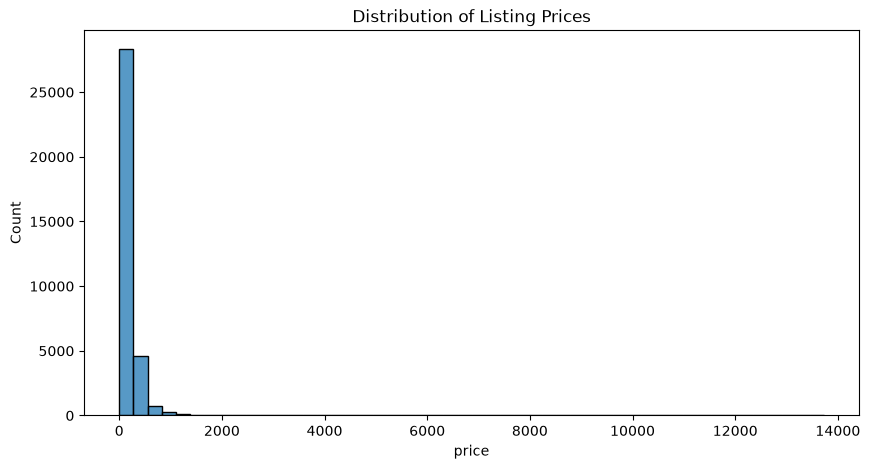

In [31]:
plt.figure(figsize=(10,5))

sns.histplot(df["price"], bins=50)

plt.title("Distribution of Listing Prices")
plt.show()


### 4.1 Outlier Treatment

Same rule as `06_random_forest.ipynb`: observations below the 1st percentile and above the 99th
percentile are removed, so both models see the same rows.


In [32]:
#outlier treatment
q1 = df["price"].quantile(0.01)
q99 = df["price"].quantile(0.99)

df = df[
    (df["price"] >= q1) &
    (df["price"] <= q99)
]

print(df.shape)


(33636, 69)


## 5. Feature Preparation for Modeling

Same as the Random Forest notebook: separate target from predictors, drop rows with a missing
target, and cast everything to float.


In [33]:
X = df.drop("price", axis=1)

print(
    X.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)


[]


In [34]:
df = df.dropna(
    subset=["price"]
)

X = df.drop("price", axis=1)

X = X.astype(float)

y = df["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", X.shape[1])
print("Remaining missing values:", df.isnull().sum().sum())


X shape: (33636, 68)
y shape: (33636,)
Number of features: 68
Remaining missing values: 100908


## 6. Train-Test Split

Same split as `06_random_forest.ipynb`: 80% training / 20% testing, `random_state=42`. Using
the identical split (same rows in train vs. test) is what makes MAE/RMSE/R² directly comparable
between the two models.


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(26908, 68)
(6728, 68)


## 7. Linear Regression Pipeline

Unlike Random Forest, Linear Regression benefits from standardized numeric features — it makes
the fitted coefficients comparable in magnitude, which we use below for a quick feature-selection
read. A `Pipeline` keeps scaling and fitting together so the scaler is fit only on training data.


In [36]:
model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression()),
])

model.fit(X_train, y_train)
print("Model fitted.")


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## 8. Model Evaluation

In [ ]:
def evaluate(model, X, y, label):
    preds = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, preds))
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)
    print(f"[{label}] RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}")
    return preds

train_preds = evaluate(model, X_train, y_train, "Train")
test_preds = evaluate(model, X_test, y_test, "Test")


Because this notebook now uses the exact same `final_dataset.csv`, preprocessing, and
train/test split as `06_random_forest.ipynb`, these numbers can be compared directly against
that notebook's optimized Random Forest results (MAE = 45.46, RMSE = 79.47, R² = 0.568).

**If R² comes out noticeably lower than Random Forest:** that's not a bug — it's a genuine
signal that price doesn't have a strong *linear* relationship with these features, which is
exactly the argument for also trying Random Forest. If train and test R²/RMSE are close to
each other, that rules out overfitting; more likely causes are (a) a few very high-priced
listings pulling the linear fit around — worth trying `np.log1p(price)` as the target instead,
or (b) genuinely non-linear effects (e.g. price jumps between neighbourhoods or room types)
that a straight line can't capture.


## 9. Residual Analysis

In [ ]:
residuals = y_test - test_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(test_preds, y_test, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
axes[0].set_xlabel("Predicted price")
axes[0].set_ylabel("Actual price")
axes[0].set_title("Predicted vs Actual (test set)")

axes[1].hist(residuals, bins=50)
axes[1].set_xlabel("Residual (actual - predicted)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()


If residuals fan out at higher prices (heteroscedasticity) or look skewed, a `log1p(price)`
target is a common fix worth trying as a variant, and is easy to justify to the group as a
follow-up experiment.


## 10. Coefficients — feature importance / interpretability

Numeric features were standardized, so coefficients are directly comparable in magnitude:
larger absolute value → stronger association with price, holding other features constant.
Useful for the Feature Selection section of the presentation, and for comparing against what
`06_random_forest.ipynb`'s feature importances found.


In [ ]:
coefficients = model.named_steps["regressor"].coef_

coef_table = (
    pd.DataFrame({"feature": X.columns, "coefficient": coefficients})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)

coef_table.head(20)


In [ ]:
plt.figure(figsize=(10,8))

top_coefs = coef_table.head(20)

sns.barplot(
    data=top_coefs,
    x="coefficient",
    y="feature",
    hue=top_coefs["coefficient"] > 0,
    dodge=False,
    legend=False,
)

plt.title("Top 20 Linear Regression Coefficients (standardized features)")
plt.xlabel("Coefficient (price impact, standard-deviation units)")
plt.show()


## 11. Conclusions

- **Data**: same `final_dataset.csv`, same preprocessing, same 80/20 split (`random_state=42`)
  as `06_random_forest.ipynb`, so results are directly comparable.
- **Model**: Linear Regression baseline in a `sklearn` Pipeline (`StandardScaler` →
  `LinearRegression`).
- Fill in the actual numbers from Section 8 above (Train/Test RMSE, MAE, R²) here once you've
  run the notebook on your data, and compare against Random Forest's MAE = 45.46,
  RMSE = 79.47, R² = 0.568.
- Use Section 10's coefficients alongside `06_random_forest.ipynb`'s feature importances for the
  Feature Selection part of the presentation — points where both models agree on which features
  matter most are a strong argument; points where they disagree are worth discussing (usually a
  sign of a non-linear or interaction effect that only Random Forest picks up).
- **Next steps to discuss as a group**: try `np.log1p(price)` as the target if residuals look
  skewed (Section 9), and consider Lasso/Ridge regression as a middle ground between Linear
  Regression and Random Forest for the "at least three different methods" requirement in the
  Price Prediction focus area.
